# Plots for the paper

In [1]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd

import warnings

warnings.filterwarnings("ignore")

### Error analysis for brownian motion

In [2]:
error_bm_df = pd.read_csv("results/error_brownian_64bit.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'results/error_brownian_64bit.csv'

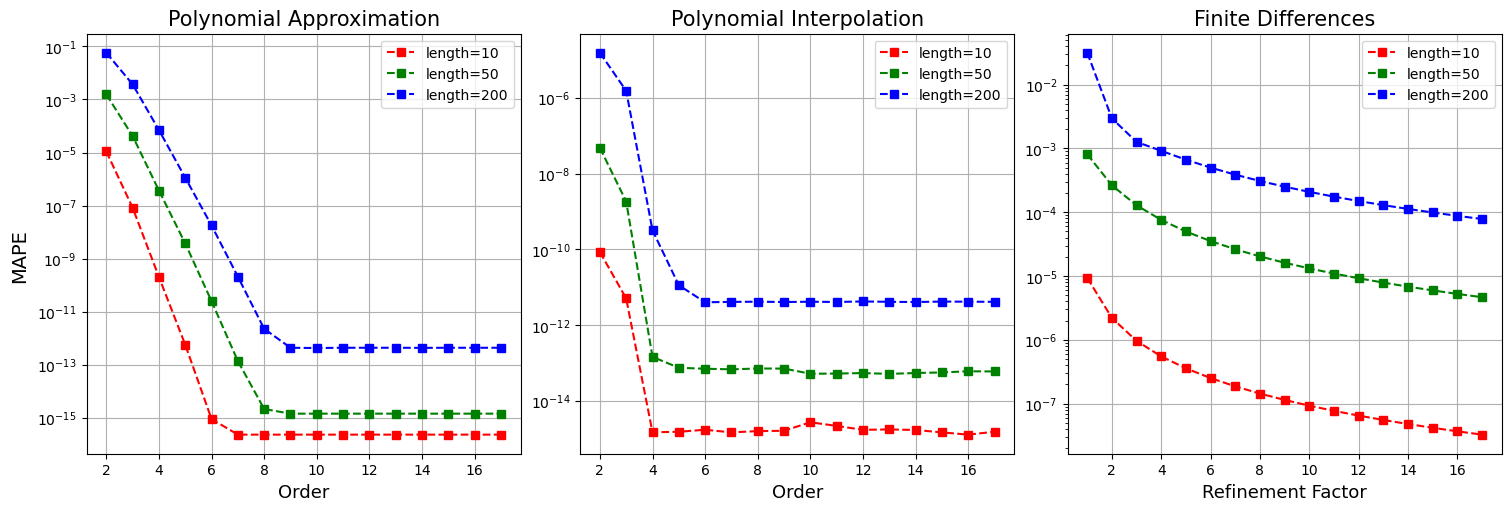

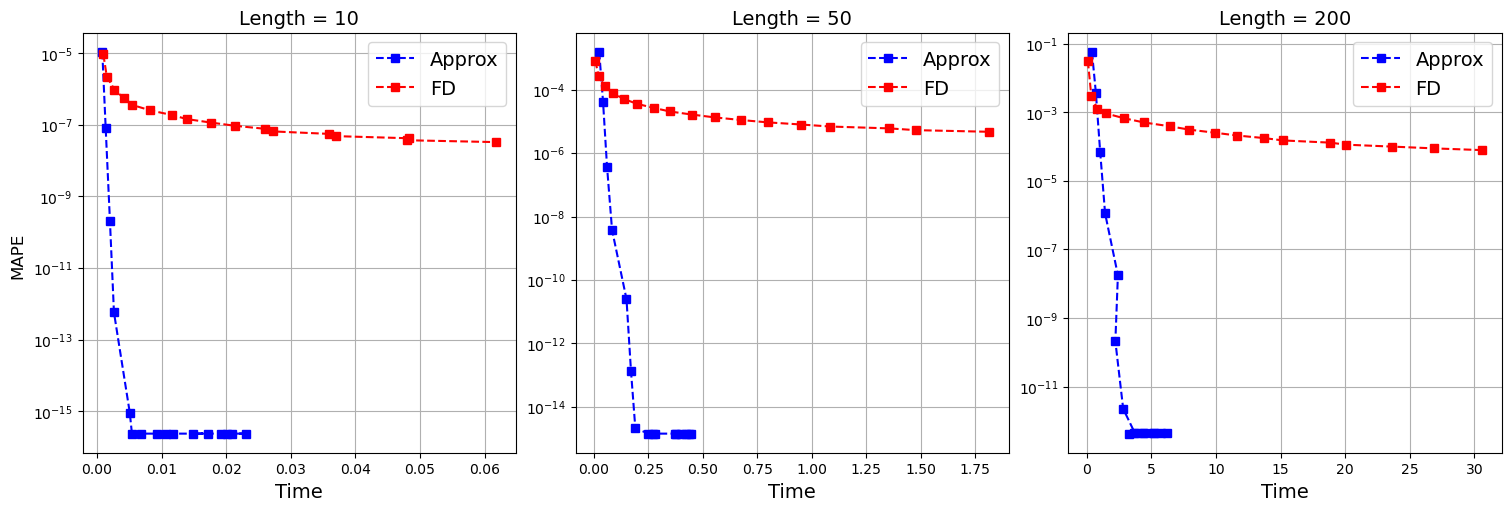

In [ ]:
models = ["monomial_approx", "monomial_interp", "sigkerax"]
names = ["Polynomial Approximation", "Polynomial Interpolation", "Finite Differences"]
colors = ["r", "g", "b"]
lengths = [10, 50, 200]
dims = [2, 3]

# Set dimension = 2 (experiments have been run also for dim = 3)
sub_df = error_bm_df[error_bm_df.dim == 2]

# Plotting the MAPE vs order / refinement factor for each model

fig, ax = plt.subplots(1, len(models), figsize=(15, 5), constrained_layout=True)


for i, (name, model) in enumerate(zip(names, models)):
    for color, length in zip(colors[: len(lengths)], lengths):
        ax[i].plot(
            sub_df[sub_df.model == model][sub_df.length == length].level,
            sub_df[sub_df.model == model][sub_df.length == length].mape,
            label=f"length={length}",
            linestyle="--",
            color=color,
            marker="s",
        )
        ax[i].set_title(name, fontsize=15)
        ax[i].grid(True)
        ax[i].set_yscale("log")

        if name == "Finite Differences":
            ax[i].set_xlabel("Refinement Factor", fontsize=13)
        else:
            ax[i].set_xlabel("Order", fontsize=13)

        ax[i].legend()

fig.supylabel("MAPE", fontsize=14)
plt.show()


# Same thing but avoid monomial interpolation
models = [
    "monomial_approx",
    "sigkerax",
]
names = ["Length = 10", "Length = 50", "Length = 200"]
model_names = ["Approx", "FD"]
colors = ["b", "r", "g"]
lengths = [10, 50, 200]
dims = [2, 3]

fig, ax = plt.subplots(1, len(lengths), figsize=(15, 5), constrained_layout=True)

sub_df = error_bm_df[error_bm_df.dim == 2]

for i, (name, length) in enumerate(zip(names, lengths)):
    for model_name, (color, model) in zip(
        model_names, zip(colors[: len(models)], models)
    ):
        ax[i].plot(
            sub_df[sub_df.model == model][sub_df.length == length].time,
            sub_df[sub_df.model == model][sub_df.length == length].mape,
            label=model_name,
            linestyle="--",
            color=color,
            marker="s",
        )
        ax[i].set_title(name, fontsize=14)
        ax[i].grid(True)
        ax[i].set_yscale("log")
        ax[i].set_xlabel("Time", fontsize=14)
        ax[i].legend(fontsize=14)

fig.supylabel("MAPE", fontsize=12)
plt.show()

In [ ]:
error_bm_df[error_bm_df.dim == 2][error_bm_df.model == "monomial_approx"][
    error_bm_df.length == 200
]

,model,device,dtype,batch_size,length,dim,level,benchmark_level,mae,mape,rmse,time
294,monomial_approx,cpu,float64,4,200,2,2,21,2.669795e+01,3.766298e+01,2.838039e+02,0.105790
295,monomial_approx,cpu,float64,4,200,2,3,21,1.197308e+00,1.867001e+00,1.252181e+01,0.378928
296,monomial_approx,cpu,float64,4,200,2,4,21,5.955703e-02,7.482268e-02,5.587165e-01,0.501820
297,monomial_approx,cpu,float64,4,200,2,5,21,1.069493e-03,1.472124e-03,1.094712e-02,0.764609
298,monomial_approx,cpu,float64,4,200,2,6,21,3.031891e-05,3.708356e-05,2.502386e-04,0.962037
299,monomial_approx,cpu,float64,4,200,2,7,21,2.662576e-07,3.418520e-07,2.208439e-06,1.128490
300,monomial_approx,cpu,float64,4,200,2,8,21,5.740091e-09,6.997670e-09,3.574750e-08,1.355149
301,monomial_approx,cpu,float64,4,200,2,9,21,1.493832e-09,1.762388e-09,1.337228e-08,1.455318
302,monomial_approx,cpu,float64,4,200,2,10,21,1.501113e-09,1.766822e-09,1.340532e-08,1.899261
303,monomial_approx,cpu,float64,4,200,2,11,21,1.501569e-09,1.767067e-09,1.340561e-08,2.098588


### Error analysis for sin and cos experiment (in appendix of the paper) 

In [ ]:
error_bm_df = pd.read_csv("results/error_sincos.csv")

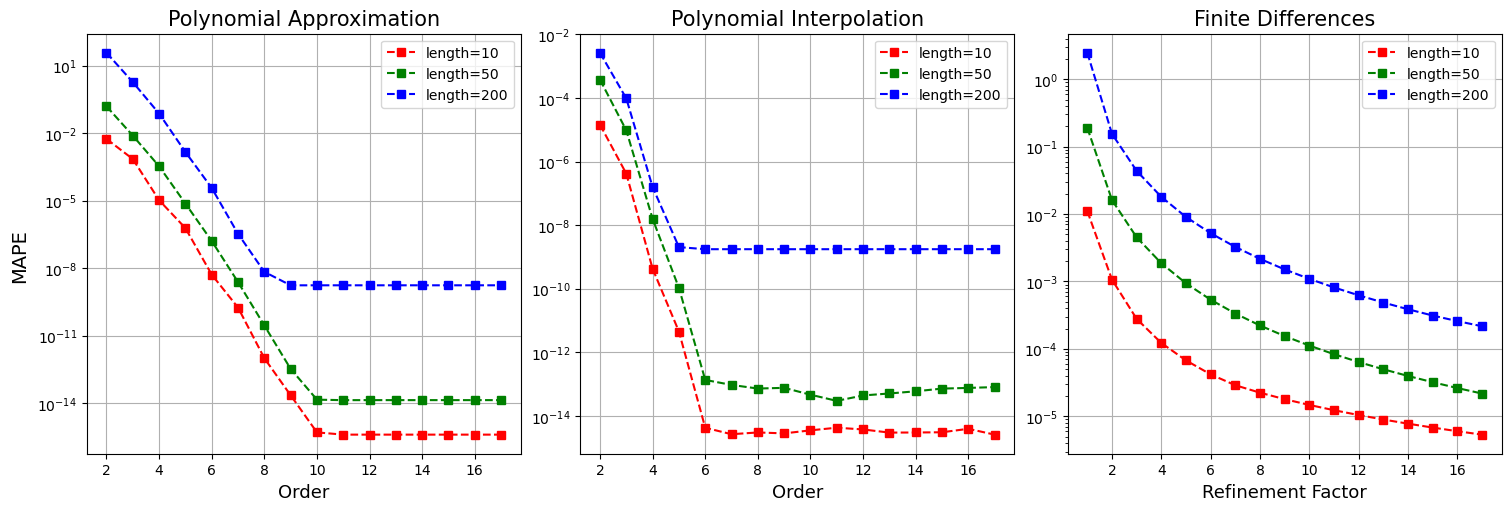

In [ ]:
models = ["monomial_approx", "monomial_interp", "sigkerax"]
names = ["Polynomial Approximation", "Polynomial Interpolation", "Finite Differences"]
colors = ["r", "g", "b"]
lengths = [10, 50, 200]
dims = [2, 3]

# Set dimension = 2 (experiments have been run also for dim = 3)
sub_df = error_bm_df[error_bm_df.dim == 2]

# Plotting the MAPE vs order / refinement factor for each model
fig, ax = plt.subplots(1, len(models), figsize=(15, 5), constrained_layout=True)

for i, (name, model) in enumerate(zip(names, models)):
    for color, length in zip(colors[: len(lengths)], lengths):
        ax[i].plot(
            sub_df[sub_df.model == model][sub_df.length == length].level,
            sub_df[sub_df.model == model][sub_df.length == length].mape,
            label=f"length={length}",
            linestyle="--",
            color=color,
            marker="s",
        )
        ax[i].set_title(name, fontsize=15)
        ax[i].grid(True)
        ax[i].set_yscale("log")

        if name == "Finite Differences":
            ax[i].set_xlabel("Refinement Factor", fontsize=13)
        else:
            ax[i].set_xlabel("Order", fontsize=13)

        ax[i].legend()

fig.supylabel("MAPE", fontsize=14)
plt.show()

### Time analysis

In [13]:
df_new = pd.read_csv("results/time_approx_gpu.csv")
df_old = pd.read_csv("results_old/time_approx.csv")
df_old_gpu = df_old[df_old.device == "gpu"]

new_length = df_new[df_new.analysis == "length"]
old_length = df_old_gpu[df_old_gpu.analysis == "length"]

new_order = df_new[df_new.analysis == "order"]
old_order = df_old_gpu[df_old_gpu.analysis == "order"]

new_dim = df_new[df_new.analysis == "dim"]
old_dim = df_old_gpu[df_old_gpu.analysis == "dim"]

LABEL_NEW_RESULTS = "New GPU"
LABEL_OLD_RESULTS = "Old GPU"

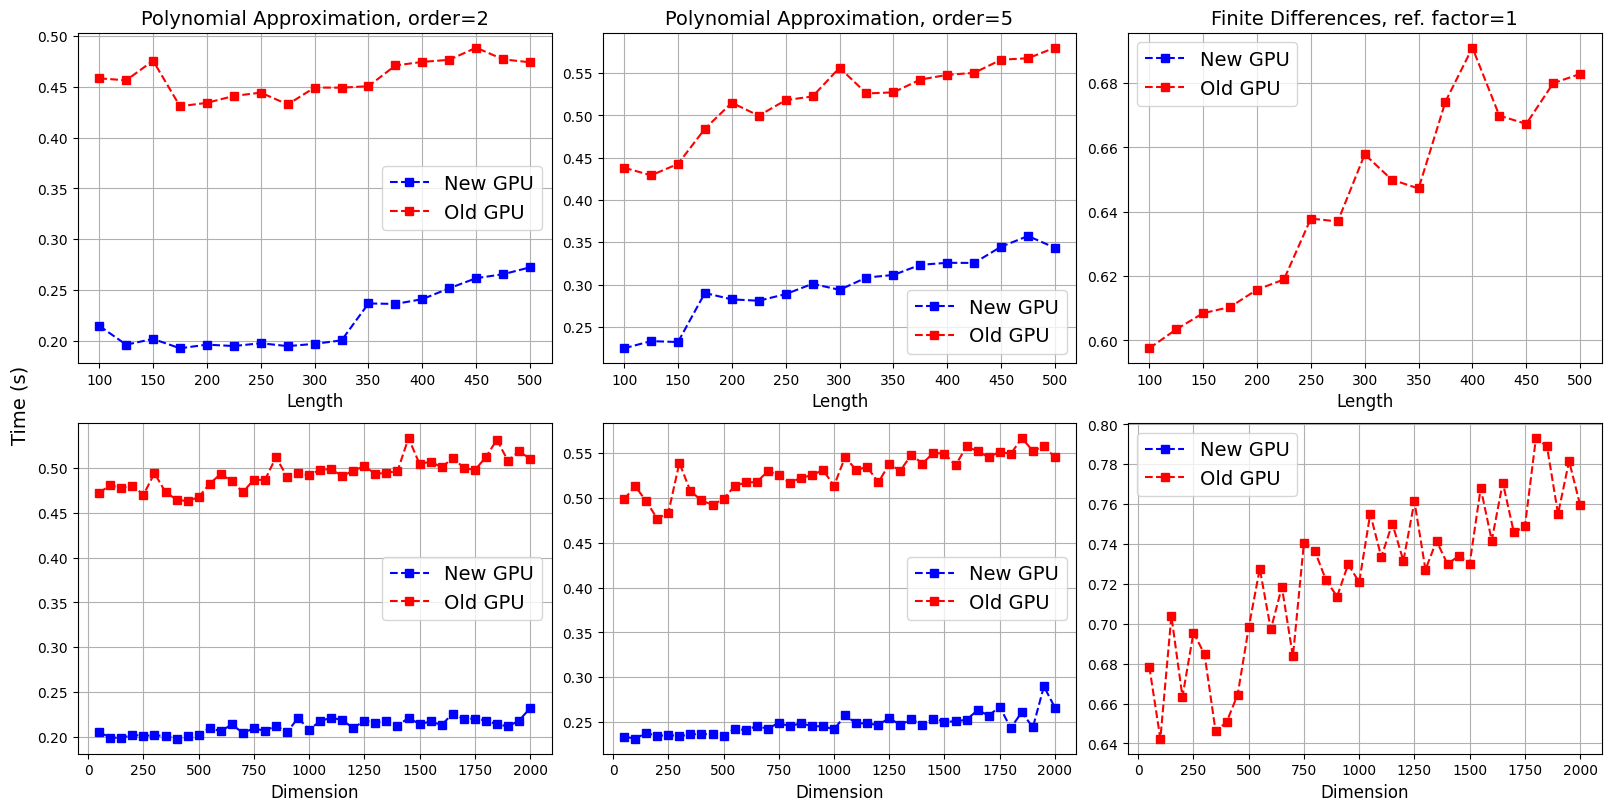

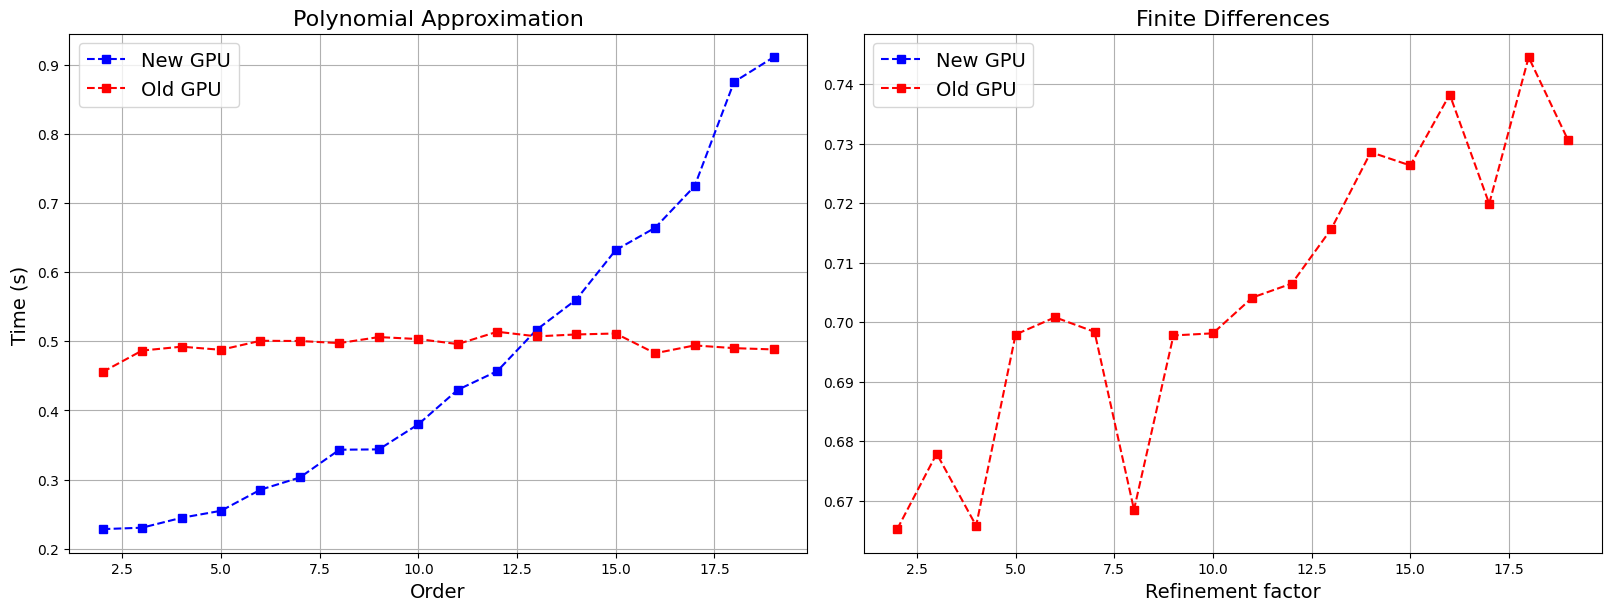

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

ax[0][0].plot(
    new_length[new_length.model == "monomial_approx"][new_length.param == 2].length,
    new_length[new_length.model == "monomial_approx"][new_length.param == 2].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0][0].plot(
    old_length[old_length.model == "monomial_approx"][old_length.param == 2].length,
    old_length[old_length.model == "monomial_approx"][old_length.param == 2].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0][1].plot(
    new_length[new_length.model == "monomial_approx"][new_length.param == 5].length,
    new_length[new_length.model == "monomial_approx"][new_length.param == 5].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0][1].plot(
    old_length[old_length.model == "monomial_approx"][old_length.param == 5].length,
    old_length[old_length.model == "monomial_approx"][old_length.param == 5].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0][2].plot(
    new_length[new_length.model == "sigkerax"][new_length.param == 1].length,
    new_length[new_length.model == "sigkerax"][new_length.param == 1].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0][2].plot(
    old_length[old_length.model == "sigkerax"][old_length.param == 1].length,
    old_length[old_length.model == "sigkerax"][old_length.param == 1].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0][0].grid()
ax[0][1].grid()
ax[0][2].grid()
ax[0][0].set_title("Polynomial Approximation, order=2", fontsize=14)
ax[0][1].set_title("Polynomial Approximation, order=5", fontsize=14)
ax[0][2].set_title("Finite Differences, ref. factor=1", fontsize=14)
ax[0][0].set_xlabel("Length", fontsize=12)
ax[0][1].set_xlabel("Length", fontsize=12)
ax[0][2].set_xlabel("Length", fontsize=12)
ax[0][0].legend(fontsize=14)
ax[0][1].legend(fontsize=14)
ax[0][2].legend(fontsize=14)

ax[1][0].plot(
    new_dim[new_dim.model == "monomial_approx"][new_dim.param == 2].dim,
    new_dim[new_dim.model == "monomial_approx"][new_dim.param == 2].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1][0].plot(
    old_dim[old_dim.model == "monomial_approx"][old_dim.param == 2].dim,
    old_dim[old_dim.model == "monomial_approx"][old_dim.param == 2].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1][1].plot(
    new_dim[new_dim.model == "monomial_approx"][new_dim.param == 5].dim,
    new_dim[new_dim.model == "monomial_approx"][new_dim.param == 5].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1][1].plot(
    old_dim[old_dim.model == "monomial_approx"][old_dim.param == 5].dim,
    old_dim[old_dim.model == "monomial_approx"][old_dim.param == 5].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1][2].plot(
    new_dim[new_dim.model == "sigkerax"][new_dim.param == 1].dim,
    new_dim[new_dim.model == "sigkerax"][new_dim.param == 1].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1][2].plot(
    old_dim[old_dim.model == "sigkerax"][old_dim.param == 1].dim,
    old_dim[old_dim.model == "sigkerax"][old_dim.param == 1].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1][0].grid()
ax[1][1].grid()
ax[1][2].grid()
ax[1][0].set_xlabel("Dimension", fontsize=12)
ax[1][1].set_xlabel("Dimension", fontsize=12)
ax[1][2].set_xlabel("Dimension", fontsize=12)
ax[1][0].legend(fontsize=14)
ax[1][1].legend(fontsize=14)
ax[1][2].legend(fontsize=14)


fig.supylabel("Time (s)", fontsize=14)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

ax[0].plot(
    new_order[new_order.model == "monomial_approx"].param,
    new_order[new_order.model == "monomial_approx"].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[0].plot(
    old_order[old_order.model == "monomial_approx"].param,
    old_order[old_order.model == "monomial_approx"].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1].plot(
    new_order[new_order.model == "sigkerax"].param,
    new_order[new_order.model == "sigkerax"].time,
    color="blue",
    label=LABEL_NEW_RESULTS,
    linestyle="--",
    marker="s",
)

ax[1].plot(
    old_order[old_order.model == "sigkerax"].param,
    old_order[old_order.model == "sigkerax"].time,
    color="red",
    label=LABEL_OLD_RESULTS,
    linestyle="--",
    marker="s",
)


ax[0].grid()
ax[1].grid()
ax[0].set_title("Polynomial Approximation", fontsize=16)
ax[1].set_title("Finite Differences", fontsize=16)
ax[0].set_xlabel("Order", fontsize=14)
ax[1].set_xlabel("Refinement factor", fontsize=14)
ax[0].legend(fontsize=14)
ax[1].legend(fontsize=14)

fig.supylabel("Time (s)", fontsize=14)
plt.show()